In [1]:
!pip install -U bitsandbytes>=0.46.1

In [2]:
import torch
import time
import gc
import os
import json
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer,
    DataCollatorForLanguageModeling, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from datasets import load_dataset
import matplotlib.pyplot as plt
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

In [3]:
# ==========================================
# КОНФИГУРАЦИЯ ИССЛЕДОВАНИЯ
# ==========================================
BASE_MODEL = "ai-forever/rugpt3medium_based_on_gpt2"
DATASET_ID = "nikrog/psychology_dataset_rus"
RESULTS_FILE = "lora_hyperparameter_study.csv"
RESPONSES_FILE = "psychology_case_responses.jsonl"  # Новый файл для ответов моделей
CASES_YAML_PATH = "/kaggle/input/datasets/nikolayart/test-cases/test_cases.yaml" # Путь к YAML с тестовыми случаями
MAX_TRAIN_SAMPLES = 2000
MAX_EVAL_SAMPLES = 200
MAX_SEQ_LENGTH = 512

# Промпт для генерации (адаптирован под стиль GPT-2/RuGPT3)
PROMPT_TEMPLATE = "Ситуация: {situation}\nРекомендация психолога:"
user_secrets = UserSecretsClient()
HGF_TOKEN = user_secrets.get_secret("HF_TOKEN")

In [4]:
HP_GRID = [
    {"r": 4, "alpha": 8, "bits": 4, "epochs": 1, "lr": 2e-4},
    {"r": 8, "alpha": 16, "bits": 4, "epochs": 1, "lr": 2e-4},
    {"r": 16, "alpha": 32, "bits": 4, "epochs": 1, "lr": 2e-4},
    {"r": 32, "alpha": 64, "bits": 4, "epochs": 1, "lr": 2e-4},
    {"r": 64, "alpha": 128, "bits": 4, "epochs": 1, "lr": 2e-4},
    {"r": 128, "alpha": 256, "bits": 4, "epochs": 1, "lr": 2e-4},
]

In [5]:
def load_test_cases(yaml_path):
    """Загрузка тестовых случаев из YAML"""
    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"Файл {yaml_path} не найден. Создайте его перед запуском.")
    with open(yaml_path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)
    return data.get('cases', [])

def load_and_prepare_data(tokenizer):
    """Загрузка и токенизация датасета"""
    print("Загрузка датасета...")
    
    data_files = {
        "train": "train.txt",
        "test": "test.txt",
        "val": "val.txt"
    }
    
    dataset = load_dataset(DATASET_ID, data_files=data_files)
    train_ds = dataset["train"].select(range(min(len(dataset["train"]), MAX_TRAIN_SAMPLES)))
    eval_ds = dataset["val"].select(range(min(len(dataset["val"]), MAX_EVAL_SAMPLES)))
    
    def tokenize_fn(examples):
        return tokenizer(examples["text"], truncation=True, max_length=MAX_SEQ_LENGTH)
    
    train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=train_ds.column_names)
    eval_ds = eval_ds.map(tokenize_fn, batched=True, remove_columns=eval_ds.column_names)
    return train_ds, eval_ds

def generate_case_responses(model, tokenizer, cases, max_new_tokens=256):
    """Генерация ответов на тестовые ситуации с замером скорости (безопасная версия)"""
    model.eval()
    responses = []
    print(f"Генерация ответов на {len(cases)} случаев...")
    
    # Гарантируем, что pad_token_id валиден
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    if tokenizer.pad_token_id is None:
        # Крайний случай: создаём токен, если совсем ничего нет
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        model.resize_token_embeddings(len(tokenizer))
    
    for idx, case in enumerate(cases):
        situation = case["situation"].strip()
        prompt = PROMPT_TEMPLATE.format(situation=situation)
        
        inputs = tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH
        ).to(model.device)
        prompt_len = inputs.input_ids.shape[1]
        
        # Явная очистка кеша перед генерацией (критично для 4-bit + LoRA)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        start_gen = time.perf_counter()
        
        try:
            with torch.inference_mode():
                outputs = model.generate(
                    inputs.input_ids,
                    max_new_tokens=max_new_tokens,
                    do_sample=True,
                    temperature=0.7,
                    top_p=0.9,
                    # Отключаем repetition_penalty для 4-bit моделей (источник багов)
                    # repetition_penalty=1.1,  # ← Закомментировано!
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                    # Явно указываем, что не нужно возвращать логины (экономит память)
                    output_scores=False,
                    return_dict_in_generate=False
                )
        except Exception as e:
            print(f"Ошибка генерации для кейса {case.get('id', idx)}: {e}")
            # Пропускаем кейс, но продолжаем выполнение
            responses.append({
                "case_id": case.get("id", idx),
                "case_title": case.get("title", ""),
                "situation": situation,
                "generated_answer": f"[ERROR: {type(e).__name__}]",
                "reference_answer": case.get("reference_answer", ""),
                "evaluation_criteria": case.get("evaluation_criteria", {}),
                "generated_tokens": 0,
                "gen_time_sec": 0.0,
                "speed_tokens_per_sec": 0.0,
                "error": str(e)
            })
            continue
            
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end_gen = time.perf_counter()
        
        gen_time = end_gen - start_gen
        generated_tokens = outputs.shape[1] - prompt_len
        speed = generated_tokens / gen_time if gen_time > 0 and generated_tokens > 0 else 0.0
        
        # Безопасный декодинг
        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        generated = full_text[len(prompt):].strip() if len(full_text) > len(prompt) else ""
        
        responses.append({
            "case_id": case["id"],
            "case_title": case["title"],
            "situation": situation,
            "generated_answer": generated,
            "reference_answer": case.get("reference_answer", ""),
            "evaluation_criteria": case.get("evaluation_criteria", {}),
            "generated_tokens": int(generated_tokens),
            "gen_time_sec": round(gen_time, 3),
            "speed_tokens_per_sec": round(speed, 2)
        })
        
        # Явно удаляем большие тензоры после каждого кейса
        del outputs, inputs, full_text, generated
        if idx % 5 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()  # Периодическая очистка, чтобы не фрагментировать память
    
    # Финальная очистка
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return responses

def run_experiment(cfg, tokenizer, train_ds, eval_ds, run_idx, test_cases):
    """Один запуск эксперимента"""
    torch.cuda.empty_cache()
    gc.collect()
    
    r, alpha, bits, epochs, lr = cfg["r"], cfg["alpha"], cfg["bits"], cfg["epochs"], cfg["lr"]
    exp_name = f"run{run_idx}_r{r}_a{alpha}_b{bits}_e{epochs}_lr{lr:.0e}"
    output_dir = os.path.join("./hp_results", exp_name)
    
    print(f"\nЗапуск: {exp_name}")
    
    # 1. Квантизация
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True if bits == 4 else False,
        load_in_8bit=True if bits == 8 else False,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True
    ) if bits in [4, 8] else None
        
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16
    )
    if bits in [4, 8]:
        model = prepare_model_for_kbit_training(model)
    
    # 2. LoRA
    lora_config = LoraConfig(
        r=r, lora_alpha=alpha, target_modules=["c_attn", "c_proj"],
        lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM
    )
    model = get_peft_model(model, lora_config)
    
    # 3. Trainer
    training_args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=lr,
        num_train_epochs=epochs,
        fp16=True,
        optim="paged_adamw_32bit",
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        eval_strategy="epoch",
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        dataloader_num_workers=2,
        warmup_ratio=0.05,
        lr_scheduler_type="cosine"
    )
    
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
    trainer = Trainer(model=model, args=training_args, train_dataset=train_ds,
                      eval_dataset=eval_ds, data_collator=collator)
    
    # 4. Обучение
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time
    
    # 5. Оценка
    metrics = trainer.evaluate()
    eval_loss = metrics.get("eval_loss", float("nan"))
    perplexity = np.exp(eval_loss) if not np.isnan(eval_loss) else float("nan")
    
    # 6. Сохранение адаптера
    trainer.save_model(output_dir)
    
    # 7. Генерация ответов на тестовые случаи
    print("Генерация ответов на психологические случаи...")
    try:
        case_responses = generate_case_responses(model, tokenizer, test_cases, max_new_tokens=256)
        with open(RESPONSES_FILE, 'a', encoding='utf-8') as f:
            for resp in case_responses:
                resp["run_idx"] = run_idx
                resp.update(cfg)  # Добавляем гиперпараметры для контекста
                f.write(json.dumps(resp, ensure_ascii=False) + "\n")
        print(f"Ответы сохранены в {RESPONSES_FILE}")
    except Exception as e:
        print(f"Ошибка при генерации ответов: {e}")
    
    # 8. Очистка
    del model, trainer, collator
    torch.cuda.empty_cache()
    gc.collect()
    
    return {
        "run_idx": run_idx,
        "r": r, "alpha": alpha, "bits": bits, "epochs": epochs, "lr": lr,
        "train_time_sec": round(train_time, 2),
        "eval_loss": round(eval_loss, 4),
        "perplexity": round(perplexity, 2),
        "status": "success"
    }

In [6]:
print("Инициализация...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

Инициализация...


config.json:   0%|          | 0.00/761 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

In [7]:
print("Загрузка тестовых случаев...")
test_cases = load_test_cases(CASES_YAML_PATH)

Загрузка тестовых случаев...


In [8]:
hf_token = HGF_TOKEN
login(token=hf_token)
print("Success authentification in Huggingface Hub")

Success authentification in Huggingface Hub


In [9]:
train_ds, eval_ds = load_and_prepare_data(tokenizer)
    
results = []
if os.path.exists(RESULTS_FILE):
    results = pd.read_csv(RESULTS_FILE).to_dict(orient="records")
    print(f"Загружено {len(results)} предыдущих записей.")

Загрузка датасета...


README.md:   0%|          | 0.00/723 [00:00<?, ?B/s]

train.txt:   0%|          | 0.00/29.5M [00:00<?, ?B/s]

test.txt:   0%|          | 0.00/2.69M [00:00<?, ?B/s]

val.txt:   0%|          | 0.00/3.14M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [10]:
start_run = len(results) + 1
for i, cfg in enumerate(HP_GRID):
    print(f"config #{i}: {cfg}")
    run_idx = start_run + i
    try:
        res = run_experiment(cfg, tokenizer, train_ds, eval_ds, run_idx, test_cases)
        results.append(res)
        pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)
        print(f"Готово. Perplexity: {res['perplexity']:.2f} | Время: {res['train_time_sec']/60:.1f} мин")
    except Exception as e:
        print(f"Ошибка в run {run_idx}: {e}")
        results.append({"run_idx": run_idx, "status": f"failed: {str(e)}", **cfg})
        pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)
        
print("\nИсследование завершено. Результаты в", RESULTS_FILE)
print("Ответы моделей сохранены в", RESPONSES_FILE)

`torch_dtype` is deprecated! Use `dtype` instead!


config #0: {'r': 4, 'alpha': 8, 'bits': 4, 'epochs': 1, 'lr': 0.0002}

Запуск: run1_r4_a8_b4_e1_lr2e-04


pytorch_model.bin:   0%|          | 0.00/1.73G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.73G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

...

Генерация ответов на психологические случаи...
Генерация ответов на 10 случаев...
Ответы сохранены в psychology_case_responses.jsonl
Готово. Perplexity: 57.07 | Время: 5.3 мин
config #5: {'r': 128, 'alpha': 256, 'bits': 4, 'epochs': 1, 'lr': 0.0002}

Запуск: run6_r128_a256_b4_e1_lr2e-04


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3medium_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,3.527474,3.905049


Генерация ответов на психологические случаи...
Генерация ответов на 10 случаев...
Ответы сохранены в psychology_case_responses.jsonl
Готово. Perplexity: 49.65 | Время: 5.3 мин

Исследование завершено. Результаты в lora_hyperparameter_study.csv
Ответы моделей сохранены в psychology_case_responses.jsonl


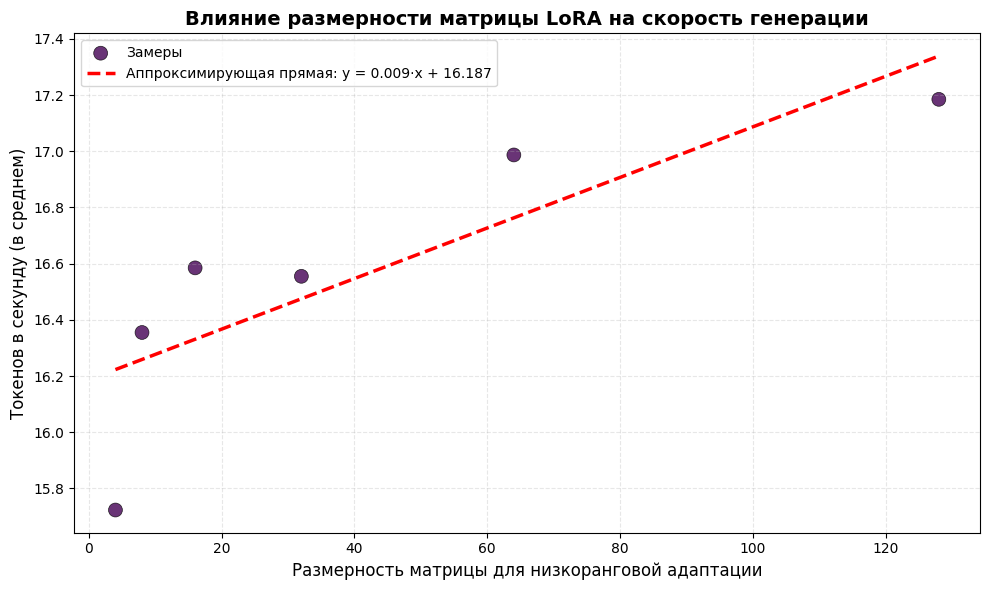


Линейная аппроксимация:
   y = +0.0090·x + +16.1869

   где: y — скорость (tok/sec), x — ранг LoRA (r)

При увеличении r на 1, скорость увеличивается на 0.01 tok/sec


In [11]:
df = pd.read_json(RESPONSES_FILE, lines=True)

speed_by_cfg = df.groupby(["run_idx", "r", "alpha", "bits"])[["gen_time_sec", "speed_tokens_per_sec"]].mean().reset_index()

x = speed_by_cfg["r"].values
y = speed_by_cfg["speed_tokens_per_sec"].values

# Линейная аппроксимация: y = k*x + b (полином 1-й степени)
k, b = np.polyfit(x, y, deg=1)

# Точки для плавной линии
x_line = np.linspace(x.min(), x.max(), 100)
y_line = k * x_line + b

# Построение графика
plt.figure(figsize=(10, 6))

# Точки экспериментов
scatter = plt.scatter(x, y, c=speed_by_cfg["bits"], cmap="viridis", 
                      s=100, alpha=0.8, edgecolors='black', linewidth=0.5,
                      label="Замеры")

# Линия аппроксимации
plt.plot(x_line, y_line, 'r--', linewidth=2.5, label=f'Аппроксимирующая прямая: y = {k:.3f}·x + {b:.3f}')

# Подписи и оформление
plt.xlabel("Размерность матрицы для низкоранговой адаптации", fontsize=12)
plt.ylabel("Токенов в секунду (в среднем)", fontsize=12)
plt.title("Влияние размерности матрицы LoRA на скорость генерации", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Вывод формулы аппроксимации
print("\nЛинейная аппроксимация:")
print(f"   y = {k:+.4f}·x + {b:+.4f}")
print(f"\n   где: y — скорость (tok/sec), x — ранг LoRA (r)")

# Интерпретация коэффициента
if k < 0:
    print(f"\nПри увеличении r на 1, скорость уменьшается на {abs(k):.2f} tok/sec")
else:
    print(f"\nПри увеличении r на 1, скорость увеличивается на {k:.2f} tok/sec")